## **LOAD DATA LAZADA**

In [1]:
import pandas as pd

In [2]:
lazada = pd.read_csv('/content/data_lazada_kotor.csv')
lazada

,link_produk,brand,harga,lokasi_toko,potongan,voucher_klaim,penjualan,jumlah_rating,keunggulan,metode_transaksi
0,https://www.lazada.co.id/products/pdp-i8415508...,Redmi 6A Cellphone Minus,Rp99.000,Kab. Bogor,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.lazada.co.id/products/pdp-i8702334...,MESIN HANDPHONE SAMSUNG A10 NO POLA,Rp275.000,Kab. Cirebon,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.lazada.co.id/products/pdp-i8645942...,Infini Smart 9 - 4/128Gb - Mediatek Helio G81 ...,Rp928.264,Kota Jakarta Selatan,23% Off,Voucher save 23%,32 sold,(7),NaN,NaN
3,https://www.lazada.co.id/products/pdp-i7722014...,mesin hp xiaomi redmi 8a pro ori cabutan normal,Rp299.900,Kab. Subang,NaN,NaN,NaN,(3),NaN,NaN
4,https://www.lazada.co.id/products/pdp-i7656644...,Hp Android Smartphone Mito A16 Ram 1/8GB 4G Fu...,Rp399.000,Kota Tangerang,5% Off,Voucher save 5%,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3995,https://www.lazada.co.id/products/pdp-i1881583...,Samsung A07,Rp1.399.000,Kota Medan,NaN,NaN,NaN,NaN,NaN,NaN
3996,https://www.lazada.co.id/products/pdp-i8419970...,Samsung Galaxy A15 8/128GB - Blue Black\n\ngar...,Rp2.300.000,Kota Jakarta Selatan,4% Off,Voucher save 4%,NaN,NaN,NaN,NaN
3997,https://www.lazada.co.id/products/pdp-i8370414...,Xiaomi Redmi A3 Official Guarantee from Xiaomi...,Rp1.000.000,Kota Jakarta Utara,NaN,NaN,NaN,(1),NaN,NaN
3998,https://www.lazada.co.id/products/pdp-i8409354...,"Nubia V70 Max 6Gb 128Gb | 6.9"" Hd+ Display 1...",Rp1.799.000,Kab. Sidoarjo,10% Off,Voucher save 10%,NaN,(1),NaN,NaN


## **PREPROCESSING**

In [3]:
# Struktur data
lazada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   link_produk       4000 non-null   object
 1   brand             4000 non-null   object
 2   harga             4000 non-null   object
 3   lokasi_toko       3995 non-null   object
 4   potongan          2436 non-null   object
 5   voucher_klaim     2088 non-null   object
 6   penjualan         1427 non-null   object
 7   jumlah_rating     1807 non-null   object
 8   keunggulan        608 non-null    object
 9   metode_transaksi  19 non-null     object
dtypes: object(10)
memory usage: 312.6+ KB


In [4]:
# Pengecekan missing value
lazada.isnull().sum()

,0
link_produk,0
brand,0
harga,0
lokasi_toko,5
potongan,1564
voucher_klaim,1912
penjualan,2573
jumlah_rating,2193
keunggulan,3392
metode_transaksi,3981


In [5]:
# Pengecekan data duplikat
lazada.duplicated().sum()

np.int64(0)

#### Seleksi Kolom (Drop yang Tidak Digunakan)

In [6]:
# Kolom yang digunakan
kolom_lazada = ['brand', 'harga', 'penjualan', 'lokasi_toko']
lazada = lazada[kolom_lazada].copy()

print("Kolom setelah diseleksi:", lazada.columns.tolist())
print("Shape:", lazada.shape)

Kolom setelah diseleksi: ['brand', 'harga', 'penjualan', 'lokasi_toko']
Shape: (4000, 4)


In [7]:
# Rename kolom
lazada = lazada.rename(columns = {
    'brand': 'Produk',
    'harga': 'Harga_Produk',
    'penjualan': 'Produk_Terjual',
    'lokasi_toko': 'Lokasi_Toko'})

print("Kolom setelah rename:", lazada.columns.tolist())

Kolom setelah rename: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko']


#### Tambahkan Kolom Identitas Platform

In [8]:
lazada['E-Commerce'] = 'lazada'
print(lazada['E-Commerce'].value_counts())

E-Commerce
lazada    4000
Name: count, dtype: int64


In [9]:
lazada.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,Redmi 6A Cellphone Minus,Rp99.000,NaN,Kab. Bogor,lazada
1,MESIN HANDPHONE SAMSUNG A10 NO POLA,Rp275.000,NaN,Kab. Cirebon,lazada
2,Infini Smart 9 - 4/128Gb - Mediatek Helio G81 ...,Rp928.264,32 sold,Kota Jakarta Selatan,lazada
3,mesin hp xiaomi redmi 8a pro ori cabutan normal,Rp299.900,NaN,Kab. Subang,lazada
4,Hp Android Smartphone Mito A16 Ram 1/8GB 4G Fu...,Rp399.000,NaN,Kota Tangerang,lazada


#### Filter Produk HP (Drop Selain Produk HP)

In [10]:
# Membuat kata kunci penanda produk non-hp
non_hp_keywords = ['headset', 'earphone', 'earbuds', 'tws', 'charger', 'casing',
                   'softcase', 'hardcase', 'tempered', 'glass', 'kabel', 'cable',
                   'powerbank', 'power bank', 'lcd', 'spare', 'baterai', 'battery',
                   'tripod', 'holder', 'stand', 'stylus', 'adapter', 'converter',
                   'memory', 'micro sd', 'microsd', 'tablet', 'smartwatch', 'watch',
                   'mesin', 'minus', 'cellphone minus', 'no pola', 'mati total', 'rusak', 'icloud']

def is_hp(judul):
    judul_lower = str(judul).lower()
    for kw in non_hp_keywords:
        if kw in judul_lower:
            return False
    return True

sebelum = lazada.shape[0]
lazada = lazada[lazada['Produk'].apply(is_hp)].reset_index(drop = True)
sesudah = lazada.shape[0]

print(f"Baris sebelum filter: {sebelum}")
print(f"Baris setelah filter: {sesudah}")
print(f"Produk non-HP yang dibuang: {sebelum - sesudah}")

Baris sebelum filter: 4000
Baris setelah filter: 3066
Produk non-HP yang dibuang: 934


#### Cleaning Kolom Harga Produk

In [11]:
lazada['Harga_Produk'] = (
    lazada['Harga_Produk']
    .astype(str)
    .str.replace('.', '', regex=False)   # hapus titik pemisah ribuan
    .str.replace(',', '', regex=False)   # hapus koma
    .str.replace('Rp', '', regex=False)  # hapus prefix Rp a
    .str.strip()                         # hapus spasi di awal/akhir
)

lazada['Harga_Produk'] = pd.to_numeric(lazada['Harga_Produk'], errors = 'coerce')

In [12]:
# Tipe data
print("Tipe data harga:", lazada['Harga_Produk'].dtype)

Tipe data harga: int64


In [13]:
# Pengecekan missing value kolom harga produk
lazada['Harga_Produk'].isnull().sum()

np.int64(0)

In [14]:
# Statistika deskriptif
lazada['Harga_Produk'].describe()

,Harga_Produk
count,3.066000e+03
mean,3.104317e+06
std,4.005317e+06
min,4.500000e+03
25%,1.200000e+06
50%,1.879000e+06
75%,3.346250e+06
max,3.925000e+07


#### Cleaning Kolom Produk Terjual

In [15]:
import numpy as np
import re

In [16]:
def parse_terjual_lazada(val):
    val = str(val).lower().strip()

    # Hapus kata sold dan terjual
    val = val.replace('sold', '').replace('terjual', '').strip()

    # Handle format "1rb+" atau "2rb"
    match_rb = re.search(r'([\d.,]+)\s*rb', val)
    if match_rb:
        angka = match_rb.group(1).replace(',', '').replace('.', '')
        return float(angka) * 1000

    # Handle format "1k+" atau "2k"
    match_k = re.search(r'([\d.,]+)\s*k', val)
    if match_k:
        angka = match_k.group(1).replace(',', '').replace('.', '')
        return float(angka) * 1000

    # Handle angka biasa "32", "150"
    val_clean = re.sub(r'[^\d]', '', val)
    if val_clean:
        return float(val_clean)

    return np.nan

lazada['Produk_Terjual'] = lazada['Produk_Terjual'].apply(parse_terjual_lazada)
lazada['Produk_Terjual'] = pd.to_numeric(lazada['Produk_Terjual'], errors = 'coerce')

In [17]:
# Tipe data
print("Tipe data terjual:", lazada['Produk_Terjual'].dtype)

Tipe data terjual: float64


In [18]:
# Pengecekan missing value
lazada['Produk_Terjual'].isnull().sum()

np.int64(2171)

In [19]:
# Statistika deskriptif
lazada['Produk_Terjual'].describe().round(3)

,Produk_Terjual
count,895.000
mean,6554.924
std,114277.996
min,5.000
25%,12.000
50%,37.000
75%,162.000
max,3380000.000


#### Cleaning Kolom Kota

In [20]:
lazada['Lokasi_Toko'].unique()

array(['Kota Tangerang', 'Kota Tangerang Selatan', 'Kab. Bandung Barat',
       'Kab. Bogor', 'Kab. Cirebon', 'Kota Jakarta Selatan',
       'Kab. Purbalingga', 'Kota Jakarta Barat', 'Kota Bekasi',
       'Kota Tasikmalaya', 'Kota Medan', 'Kota Jakarta Pusat',
       'Kota Depok', 'Kota Surabaya', 'Kota Palembang', 'Kab. Tangerang',
       'Kab. Jember', 'Kota Jakarta Utara', 'Kab. Purwakarta',
       'Kab. Wonogiri', 'Kab. Sidoarjo', 'Kab. Brebes', 'Kab. Bekasi',
       'Kota Jakarta Timur', 'Kota Bandung', 'Kota Semarang',
       'Kota Makassar', 'Kab. Indramayu', 'Kota Pekanbaru',
       'Kab. Banyuwangi', 'Kab. Banjarnegara', 'Kab. Majalengka',
       'Kab. Sumedang', 'Kab. Bangka Barat', 'Kab. Kotabaru',
       'Kab. Sukabumi', 'Kab. Nganjuk', 'Kab. Subang', 'Kota Bogor',
       'Kota Cilegon', 'Kab. Karawang', 'Kab. Ciamis', 'Kab. Ngawi', nan,
       'Kab. Garut', 'Kab. Muaro Jambi', 'Kota Madiun', 'Kota Kediri',
       'Kab. Cianjur', 'Kab. Tuban', 'Kota Batu', 'Kota Binjai',
  

In [21]:
def normalize_location(location):
    if pd.isna(location):
        return np.nan

    original_lower = str(location).lower().strip()

    direct_map = {
        'kota surakarta (solo)': 'surakarta (kota)',
        'solo': 'surakarta (kota)',
        'kota tangerang selatan': 'tangerang selatan (kota)',
        'kab. bandung barat': 'bandung barat (kabupaten)',
        'kab. muaro jambi': 'muaro jambi (kabupaten)',
        'kab. deli serdang': 'deli serdang (kabupaten)',
        'kab. ogan komering ilir': 'ogan komering ilir (kabupaten)',
        'kab. lampung utara': 'lampung utara (kabupaten)',
        'kota jakarta selatan': 'jakarta selatan (kota)',
        'kota jakarta pusat': 'jakarta pusat (kota)',
        'kota jakarta barat': 'jakarta barat (kota)',
        'kota jakarta timur': 'jakarta timur (kota)',
        'kota jakarta utara': 'jakarta utara (kota)',
    }

    if original_lower in direct_map:
        return direct_map[original_lower]

    if 'kabupaten' in original_lower:
        name = original_lower.replace('kabupaten', '').strip()
        name = name.replace('kab.', '').strip()
        return f'{name} (kabupaten)' if name else original_lower + ' (kabupaten)'
    elif 'kab.' in original_lower:
        name = original_lower.replace('kab.', '').strip()
        return f'{name} (kabupaten)' if name else original_lower + ' (kabupaten)'
    elif 'kota' in original_lower:
        name = original_lower.replace('kota', '').strip()
        return f'{name} (kota)' if name else original_lower + ' (kota)'

    cities_no_prefix = [
        'tangerang', 'bekasi', 'medan', 'depok', 'surabaya', 'palembang', 'tasikmalaya',
        'bogor', 'cilegon', 'madiun', 'kediri', 'cianjur', 'batu', 'binjai',
        'balikpapan', 'malang', 'denpasar', 'pontianak', 'cirebon', 'cimahi',
        'tegal', 'sukabumi', 'mataram', 'manado', 'semarang', 'makassar', 'pekanbaru', 'serang',
        'bandung'
    ]

    regencies_no_prefix = [
        'jember', 'purbalingga', 'purwakarta', 'wonogiri', 'sidoarjo', 'brebes',
        'indramayu', 'banyuwangi', 'banjarnegara', 'majalengka', 'sumedang', 'bangka barat',
        'kotabaru', 'nganjuk', 'subang', 'karawang', 'ciamis', 'ngawi', 'garut',
        'tuban', 'karanganyar', 'pasuruan', 'probolinggo', 'sleman', 'demak',
        'tabalong', 'cilacap', 'rembang', 'sukoharjo', 'pinrang', 'banjar',
        'lebak', 'kuningan', 'boyolali', 'kudus', 'gresik', 'bengkalis', 'trenggalek',
        'jepara', 'kebumen', 'pandeglang', 'kendal', 'lamongan', 'magetan',
        'pati', 'banyumas', 'mojokerto'
    ]

    if original_lower in cities_no_prefix:
        return f'{original_lower} (kota)'
    elif original_lower in regencies_no_prefix:
        return f'{original_lower} (kabupaten)'
    return original_lower

In [22]:
lazada['Lokasi_Toko'] = lazada['Lokasi_Toko'].apply(normalize_location)

# Jumlah lokasi setelah di normalisasi
lazada['Lokasi_Toko'].value_counts()

,count
Lokasi_Toko,
jakarta barat (kota),585
surabaya (kota),293
jakarta selatan (kota),270
jakarta pusat (kota),250
jakarta utara (kota),238
...,...
kendal (kabupaten),1
manado (kota),1
pati (kabupaten),1


#### Penanganan Missing Value

In [23]:
print("Missing values sebelum ditangani:\n")
lazada.isnull().sum()

Missing values sebelum ditangani:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,2171
Lokasi_Toko,5
E-Commerce,0


In [24]:
# Kolom Terjual (imputasi dengan 0 (tidak diketahui = anggap belum terjual))
lazada['Produk_Terjual'] = lazada['Produk_Terjual'].fillna(0)
print(f"Produk Terjual diimputasi dengan 0: {lazada['Produk_Terjual'].isnull().sum()}")

# Kolom Lokasi (imputasi dengan modus (kota terbanyak))
lazada['Lokasi_Toko'] = lazada['Lokasi_Toko'].fillna('Tidak Diketahui')
print(f"Lokasi null diisi 'Tidak Diketahui': {(lazada['Lokasi_Toko'] == 'Tidak Diketahui').sum()} baris")

Produk Terjual diimputasi dengan 0: 0
Lokasi null diisi 'Tidak Diketahui': 5 baris


In [25]:
print("Missing values setelah imputasi:\n")
lazada.isnull().sum()

Missing values setelah imputasi:



,0
Produk,0
Harga_Produk,0
Produk_Terjual,0
Lokasi_Toko,0
E-Commerce,0


## **VISUALISASI DAN PENYIMPANAN DATASET**

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

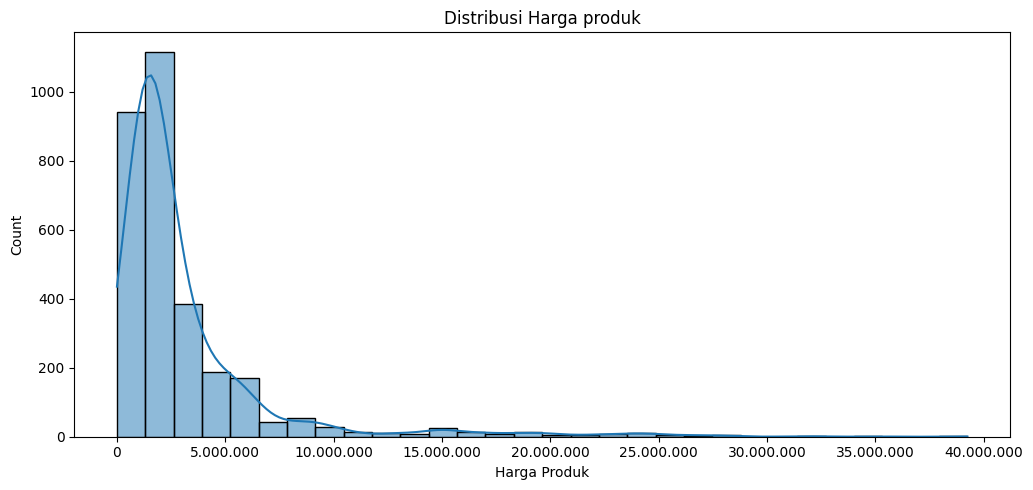

In [27]:
plt.figure(figsize = (20, 5))

# Plot 1: Distribusi dari Harga Produk
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(lazada['Harga_Produk'], bins = 30, kde = True)
plt.title('Distribusi Harga produk')
plt.xlabel('Harga Produk')
plt.ylabel('Count')

# Format x-axis labels (agar menampilkan angka harga lengkap dengan pemisah titik)
def currency_formatter(x, pos):
    return f'{int(x):,}'.replace(',', '.')

formatter = mticker.FuncFormatter(currency_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

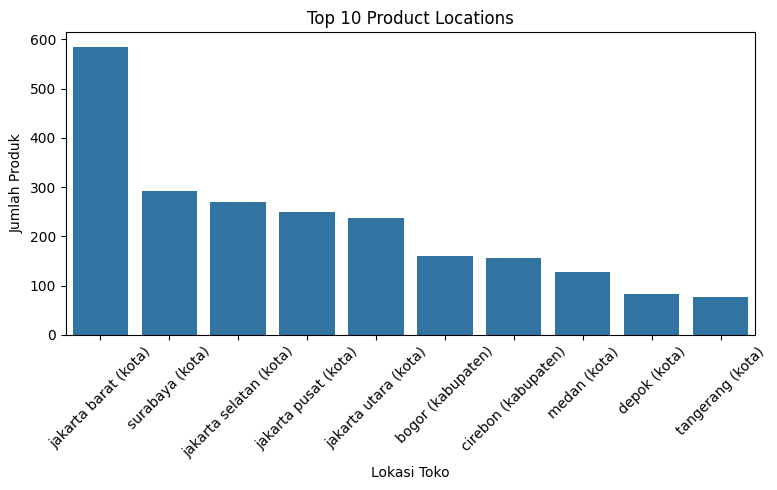

In [28]:
plt.figure(figsize = (15, 5))

# Plot 2: Top 10 dari Lokasi Toko
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
top_locations = lazada['Lokasi_Toko'].value_counts().head(10)
sns.barplot(x = top_locations.index, y = top_locations.values)
plt.title('Top 10 Product Locations')
plt.xlabel('Lokasi Toko')
plt.ylabel('Jumlah Produk')
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

#### Penyimpanan Data

In [29]:
# Jumlah akhir data lazada
print(f"Jumlah Data Setelah Preprocessing: {lazada.shape[0]} baris, {lazada.shape[1]} kolom")

Jumlah Data Setelah Preprocessing: 3066 baris, 5 kolom


In [30]:
# Nama kolom
print(f"Kolom: {lazada.columns.tolist()}")

Kolom: ['Produk', 'Harga_Produk', 'Produk_Terjual', 'Lokasi_Toko', 'E-Commerce']


In [31]:
# Pengecekan data
lazada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066 entries, 0 to 3065
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Produk          3066 non-null   object 
 1   Harga_Produk    3066 non-null   int64  
 2   Produk_Terjual  3066 non-null   float64
 3   Lokasi_Toko     3066 non-null   object 
 4   E-Commerce      3066 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 119.9+ KB


In [32]:
# Statistika deskriptif
lazada.describe().round(3)

,Harga_Produk,Produk_Terjual
count,3.066000e+03,3066.000
mean,3.104317e+06,1913.456
std,4.005317e+06,61790.541
min,4.500000e+03,0.000
25%,1.200000e+06,0.000
50%,1.879000e+06,0.000
75%,3.346250e+06,8.000
max,3.925000e+07,3380000.000


In [33]:
# Data final
lazada.head()

,Produk,Harga_Produk,Produk_Terjual,Lokasi_Toko,E-Commerce
0,Hp Android Smartphone Mito A16 Ram 1/8GB 4G Fu...,399000,0.0,tangerang (kota),lazada
1,Xiaomi Mi A1 4/64,1000000,0.0,tangerang selatan (kota),lazada
2,INFINIX SMART 8 RAM 4GB 128GB,1299000,0.0,bandung barat (kabupaten),lazada
3,Growths - Infinix Smart 7 4/64GB,1100000,13.0,bogor (kabupaten),lazada
4,Xiaomi Redmi 6A RAM 2/16GB Bekas termurah,290000,94.0,cirebon (kabupaten),lazada


In [34]:
# Simpan hasil
lazada.to_csv('data_lazada_clean.csv', index = False)
print("File _data_lazada_clean.csv berhasil disimpan!")

File _data_lazada_clean.csv berhasil disimpan!
